<a href="https://colab.research.google.com/github/smell0of0chamomile/Zeebeck_coefficient/blob/main/Computing_Seebeck_coefficient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Seebeck coefficient calculation in bipolaron–delocalized carrier model.

The script:
- Reads experimental data blocks
- Computes chemical potential correction via Hall concentration
- Calculates Seebeck coefficient using:
    * Mott formula
    * Semi-classical Fermi integral model (r = 0 or 1)
- Plots S(T) for different doping levels p

Units:
    k_B in eV/K
    Chemical potential in eV
    Temperature in K
    Lattice constant in Å


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import io
import csv
import math
from scipy.integrate import quad

In [3]:
!wget 'https://raw.githubusercontent.com/smell0of0chamomile/Zeebeck_coefficient/refs/heads/main/0.25%2C30%2C40%2C1layer%2CRmin%3D6.31%2Cm%3D1.2.txt'

--2026-03-07 09:42:46--  https://raw.githubusercontent.com/smell0of0chamomile/Zeebeck_coefficient/refs/heads/main/0.25%2C30%2C40%2C1layer%2CRmin%3D6.31%2Cm%3D1.2.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7431 (7.3K) [text/plain]
Saving to: ‘0.25,30,40,1layer,Rmin=6.31,m=1.2.txt’

0.25,30,40,1layer,R 100%[===================>]   7.26K  --.-KB/s    in 0s      

2026-03-07 09:42:46 (84.7 MB/s) - ‘0.25,30,40,1layer,Rmin=6.31,m=1.2.txt’ saved [7431/7431]



In [4]:
INPUT_TXT = "0.25,30,40,1layer,Rmin=6.31,m=1.2.txt"

In [5]:
kbol = 8.617e-5 # Boltzmann constant [eV/K]
c = 0.00352
a = 3.86 # lattice constant [Å]


# --- Global model switches ---
 MODE and n control which physical model is used in the calculations.

 MODE:


    mott_el:  – metallic regime (Mott formula for Seebeck coefficient)
    semi_0:   – semiconductor model using Fermi–Dirac integrals with r = 0
                (acoustic phonon scattering)
    semi_1:   – semiconductor model using Fermi–Dirac integrals with r = 1
                (ionized impurity scattering)

 n:


    ndeloc:   – use delocalized carrier density directly
    n_H:      – apply effective Hall carrier density correction
                     and adjust chemical potential

 These switches allow comparing different transport descriptions
 within the two-liquid model.

In [6]:
MODE = "semi_1" # "mott_el" "mott" "semi_0"
n = "n_H" #"ndeloc"


# Numerical Fermi-Dirac integral:

$$
       F_j(\eta) = \int_0^{\infty} \frac{x^j}{e^{x-\eta}+1} dx
$$

  Uses asymptotic exponential tail for large x
  to avoid overflow in integration.

    Parameters
    ----------
    j : float
        Order of the integral
    eta : float
        Reduced chemical potential μ / (k_B T)

  Returns
  -------
  float
      Value of F_j(η)
  

In [7]:
#Интеграл ферми дирака, который используем в функции seebek
def fermi_dirac_j(j, eta):

  delta = 700
  x0 = eta + delta

  # Первая часть: интегрируем от 0 до x0 с оригинальным интегрантом
  integrand1 = lambda x: x ** j / (np.exp(x - eta) + 1)
  result1, error1 = quad(integrand1, 0, x0, limit=1000)

  # Вторая часть: интегрируем от x0 до бесконечности, используя асимптотику:
  integrand2 = lambda x: x ** j * np.exp(eta - x)
  result2, error2 = quad(integrand2, x0, np.inf, limit=1000)

  return result1 + result2


    Semi-classical Seebeck coefficient:
$$
S = k_B \left(
\frac{(r+2)F_{r+1}(\eta)}{(r+1)F_r(\eta)} - \eta
\right)
$$
    r : scattering parameter
        r = 0  → acoustic phonon scattering
        r = 1  → ionized impurity scattering
  

In [8]:
def seebeck(eta, r):

  F_r = fermi_dirac_j(r, eta)
  F_r1 = fermi_dirac_j(r + 1, eta)
  S = kbol * (((r + 2) * F_r1) / ((r + 1) * F_r) - eta)
  return S


In [9]:
def compute_eta(chem_pot, T):
    return chem_pot / (kbol * T)

# --- Two-liquid model: effective Hall density and μ correction ---

 Charge system consists of:
   (1) autolocalized carriers (bipolarons)
   (2) delocalized Fermi-like carriers

 Bare 2D density:
$$
   n1 = p / a^2
$$
 Fermi-liquid limit density:
$$  
   n2 = (p + 1) / a^2
$$
 Bipolaron fraction:
$$  
   K1 = nbip / n1
$$
 Effective Hall density:
$$  
   n_H = K1*n1 + (1-K1)*n2/K2
$$
 Chemical potential is corrected assuming μ ∝ n:
$$  
   Δμ ∝ (n_H − n1)
$$
 This ensures that transport coefficients are calculated
 using effective Fermi-surface carrier density.


In [10]:
def n_H_del(p, chem_pot,nbip,ndeloc):
    if n =="ndeloc":
        return chem_pot, ndeloc
    elif n == "n_H":
        n1 = p/3.86**2
        K1 = nbip / n1
        n2 = (p+1)/3.86**2
        Ao = 11.999
        p0 = 0.09523
        B = 2.422
        a = ndeloc*3.86**2
        K2 = 1 + Ao * np.exp(- ( a / p0)**B)
        n_H = n1*K1 + (1-K1)*n2/K2
        dn = n_H - p/3.86**2
        #chem_pot = 3.61*math.pi*2*n_H
        chem_pot_dn = chem_pot + 6.28*3.61* dn
        ndeloc_H = n_H - nbip
        return chem_pot_dn , ndeloc_H
    else:
        raise ValueError("Unknown n")

In [11]:
def compute_S(T, p, chem_pot):
    if MODE == "mott_el":
        return math.pi**2 * kbol**2 * T/(chem_pot * 3)
    elif MODE == "semi_0":
        etta = compute_eta(chem_pot, T)
        return -seebeck(etta, 0)
    elif MODE == "semi_1":
        etta = compute_eta(chem_pot, T)
        return -seebeck( etta, 1)
    else:
        raise ValueError("Unknown MODE")

/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:607: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:609: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagie(func, bound, infbounds, args, full_output,


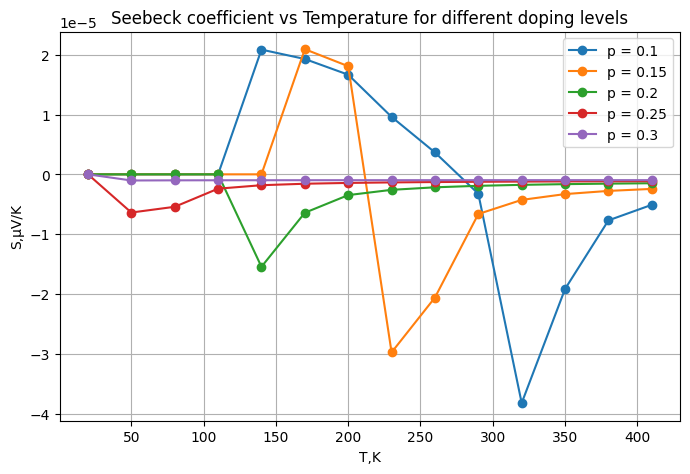

In [12]:
def read_record(lines, i):

    # Reads one physical data record (13 numerical values)
    # from the input file. A single record may span multiple lines.
    #
    # Each record corresponds to fixed doping p and temperature T.
    # Returns:
    #   nums – list of 13 floats
    #   i    – updated line index

    line_parts = []
    while len(line_parts) < 13 and i < len(lines):
        line_parts += lines[i].split()
        i += 1

    if len(line_parts) < 13:
        return None, i

    nums = [float(x.replace(',', '')) for x in line_parts[:13]]
    return nums, i

block_data = []
def compute_seebeck_point(nums):

    # Computes total Seebeck coefficient for one (p, T) point.
    #
    # Input:
    #   nums – 13-element data record from input file
    #
    # Includes:
    #   • bipolaron contribution
    #   • delocalized carrier contribution
    #   • chemical potential
    #
    # If condensate is present (ncond > 0),
    # Seebeck coefficient is set to zero.

    p  = nums[0]
    T  = nums[1]
    chem_pot = nums[9]
    nbip_r = nums[8]
    R = nums[2]
    ncond = nums[12]

    # --- Carrier densities initialization ---
    # nbip_r – raw bipolaron density from input file
    # R – radius of bipolaron
    nbip = nbip_r / (4 * R**2)

    # Total 2D carrier density is p / a^2 (a = 3.86 Å)
    # Delocalized carrier density is reduced by bipolaron fraction
    ndeloc = p / a**2 - nbip

    # --- Weight factors for two-liquid contributions ---
    # c – phenomenological scale parameter (c = 0.00352)
    # weights interpolate between bipolaron and delocalized regimes
    w_bip = 1 / (1 + c / nbip) if nbip != 0 else 0
    w_deloc = 1 / (1 + nbip / c)

    # --- Bipolaron Seebeck contribution ---
    # Estimated within electron-gas model approximation
    # (S_bip ≈ k_B / 2e_bip)
    S_bip = 2 * 2.15e-5

    # Correct chemical potential using effective Hall density
    chem_pot, ndeloc = n_H_del(p, chem_pot, nbip, ndeloc)

    # Delocalized carrier contribution
    S_deloc = compute_S(T, p, chem_pot)

    # Total Seebeck coefficient (two-liquid mixture)
    S = S_deloc * w_deloc + w_bip * S_bip

    # In superconducting (condensed) state thermopower vanishes
    if ncond > 0:
        S = 0

    return p, T, S, chem_pot,ndeloc


def extend_block(p, start_index, chem_pot,ndeloc):
    results = []
    # Extends temperature series for fixed doping p
    # up to reference length (14 temperature points).
    #
    # This ensures identical temperature range for all dopings
    # and allows analysis of high-T regime where bipolarons dissociate.
    for n in range(start_index, 14):
        T = 20 + n * 30
        nbip = 0
        chem_pot, ndeloc = n_H_del(p, chem_pot,nbip,ndeloc)
        S = compute_S(T, p, chem_pot)
        results.append((T, S))

    return results


def process_file(path):

    # Main data-processing routine.
    #
    # Reads input file consisting of doping blocks.
    # Each block starts with integer n – number of temperature points.
    #
    # For each block (fixed p):
    #   • reads n physical records
    #   • computes Seebeck coefficient for each (p, T)
    #   • extends temperature series up to 14 points if needed
    #
    # Returns:
    #   all_blocks – list of tuples (p, T_list, S_list)

    with open(path, 'r') as fin:
        lines = fin.readlines()

    i = 0
    all_blocks = []

    while i < len(lines):
        # First line of block: number of temperature records
        n = int(lines[i].strip())
        i += 1

        # Containers for one doping block (fixed p)
        T_list = []
        S_list = []
        p_block = None
        # --- Process n temperature records for current doping ---
        for _ in range(n):
            nums, i = read_record(lines, i)
            # Compute Seebeck coefficient for current (p, T)
            p, T, S, chem_pot,ndeloc = compute_seebeck_point(nums)
            # Store doping value once per block
            if p_block is None:
                p_block = p

            T_list.append(T)
            S_list.append(S)
        # --- Extend temperature grid to reference length (14 points) ---
        if p_block is not None and len(T_list) < 14:

            extended = extend_block(p_block, len(T_list),chem_pot,ndeloc)

            for T_ext, S_ext in extended:
                T_list.append(T_ext)
                S_list.append(S_ext)


        # Save results for current doping
        all_blocks.append((p_block, T_list, S_list))

    return all_blocks


def plot_blocks(block_data):
    # Plots Seebeck coefficient S(T) for all doping blocks
    fig, ax = plt.subplots(figsize=(7, 5))
    # Skip first block if it is reference/test data
    for (p_block, T_list, S_list) in block_data[1:]:
        ax.plot(T_list, S_list, marker='o', linestyle='-',
                label=f'p = {p_block}')

    ax.set_xlabel('T,K')
    ax.set_ylabel('S,μV/K')
    ax.set_title("Seebeck coefficient vs Temperature for different doping levels")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":

    # Read input data and process all doping blocks
    block_data = process_file(INPUT_TXT)
    # Plot resulting Seebeck curves
    plot_blocks(block_data)

